# Pothole Detection — Main Training Notebook

**BINUS University · Semester 4 · Computer Vision Final Project**

Pipeline deteksi lubang jalan menggunakan computer vision tradisional (tanpa deep learning).  
Empat model dibandingkan:

| # | Model | Tipe | Keterangan |
|---|-------|------|------------|
| 1 | **Baseline** | Unsupervised | Adaptive Thresholding |
| 2 | **Advanced** | Unsupervised | K-Means Pixel Clustering |
| 3 | **RF-4ch** | Supervised | Random Forest + SLIC (4 fitur dasar) |
| 4 | **RF-10ch** | Supervised | Random Forest + SLIC (10 fitur lengkap) |

---
**Urutan eksekusi:**
1. **Bagian 0–1** — Setup & fungsi pipeline (wajib dijalankan sekali)
2. **Bagian 2** — Inspeksi dataset (opsional)
3. **Bagian 3–4** — Baseline & K-Means (langsung bisa dijalankan)
4. **Bagian 5** — RF: jalankan cell training dulu, lalu evaluasi
5. **Bagian 6–7** — Ringkasan & prediksi test set

# 0 - Setup

In [15]:
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from skimage.segmentation import slic

random.seed(42)
np.random.seed(42)
print('Import selesai.')

Import selesai.


In [47]:
# Path
ROOT          = Path('..').resolve()
TRAIN_IMG_DIR = ROOT / 'Dataset' / 'train' / 'images'
TRAIN_MSK_DIR = ROOT / 'Dataset' / 'train' / 'mask'
TEST_IMG_DIR  = ROOT / 'Dataset' / 'test'  / 'images'
MODEL_DIR     = ROOT / 'model'
RESULTS_DIR   = ROOT / 'results'
PRED_DIR      = ROOT / 'predictions'
for d in [MODEL_DIR, RESULTS_DIR, PRED_DIR]:
    d.mkdir(exist_ok=True)

# CSV superpixel (dibuat di Bagian 2C, dipakai saat training RF di Bagian 5)
SP_CSV       = RESULTS_DIR / 'superpixel_features.csv'
SP_TRAIN_CSV = RESULTS_DIR / 'sp_train.csv'
SP_VAL_CSV   = RESULTS_DIR / 'sp_val.csv'

# Skala kerja
WORK_SCALE  = 0.5    # skala saat inferensi
TRAIN_SCALE = 0.5    # skala saat ekstraksi fitur (lebih kecil = lebih cepat)

# Preprocessing
ILLUM_SIGMA  = 101   # sigma Gaussian estimasi pencahayaan (harus ganjil)
CLAHE_CLIP   = 2.5
CLAHE_GRID   = 8
TOP_CROP_PCT = 0.10  # abaikan 10% atas (zona langit/horizon)

# Segmentasi jalan
SKY_HUE_LOW  = 85    # deteksi langit biru/abu di separuh atas gambar
SKY_HUE_HIGH = 140
SKY_SAT_MAX  = 130
SKY_VAL_MIN  = 80
VEG_HUE_LOW  = 20    # deteksi rumput/vegetasi hijau di seluruh gambar
VEG_HUE_HIGH = 85
VEG_SAT_MIN  = 40
ROAD_MORPH_K = 7

# SLIC superpixel
SLIC_N_SEG   = 250
SLIC_COMPACT = 10.0

# Labeling superpixel untuk training RF
SP_THRESHOLD = 0.30  # superpixel = lubang jika >= 30% pixel-nya masuk GT mask

# Random Forest
RF_N_EST     = 150
RF_MAX_DEPTH = 20
RF_MIN_LEAF  = 5
RF_SEED      = 42

# Post-processing
POSTPROC_K = 5       # kernel morphological close/open
MIN_AREA   = 500     # hapus deteksi lebih kecil dari ini (piksel)
MASK_THRESH = 127    # binarisasi mask: > 127 = positif

# Demo & split
DEMO_IMAGE_IDX  = 18     # ubah angka ini untuk demo gambar yang berbeda (0–497)
TRAIN_VAL_SPLIT = 0.80  # 80% gambar untuk training RF, 20% untuk test

print('Konfigurasi siap.')

Konfigurasi siap.


# 1. Pipeline Function

In [ ]:
# 1.1 Preprocessing

def normalize_illumination(gray):
    """Koreksi bayangan: bagi tiap piksel dengan estimasi pencahayaan lokal.
    Hasilnya: area bayangan terang kembali tanpa mengubah tekstur relatif."""
    ksize = ILLUM_SIGMA if ILLUM_SIGMA % 2 == 1 else ILLUM_SIGMA + 1
    illum = cv2.GaussianBlur(gray.astype(np.float32), (ksize, ksize), 0)
    norm  = gray.astype(np.float32) / (illum + 1e-6) * 128.0
    return np.clip(norm, 0, 255).astype(np.uint8)


def preprocess(bgr):
    """BGR → 1-channel uint8 siap dipakai ekstraksi fitur.
    Urutan: LAB L-channel → koreksi pencahayaan → CLAHE → bilateral filter."""
    L      = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)[:, :, 0]
    L_norm = normalize_illumination(L)
    clahe  = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=(CLAHE_GRID, CLAHE_GRID))
    L_eq   = clahe.apply(L_norm)
    return cv2.bilateralFilter(L_eq, d=9, sigmaColor=50, sigmaSpace=50)


print('Preprocessing OK.')

Preprocessing OK.


In [ ]:
# 1.2 Segmentasi Jalan

def segment_road(bgr):
    
    """
    Tahap 1: Mask langit (hue biru, hanya separuh atas supaya tidak salah mask jalan)
    Tahap 2: Mask vegetasi/rumput (hue hijau, green channel > red channel)
    Tahap 3: Gabungkan → balikkan → kandidat jalan
    Tahap 4: Pilih komponen terbesar yang paling bawah (= area jalan)
    Fallback: estimasi horizon dari Canny jika segmentasi gagal
    """
    h, w = bgr.shape[:2]
    hsv  = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)

    # Langit hanya di separuh atas gambar
    sky_mask         = np.zeros((h, w), dtype=np.uint8)
    top_h            = h // 2
    sky_region       = (
        (H[:top_h] >= SKY_HUE_LOW) & (H[:top_h] <= SKY_HUE_HIGH) &
        (S[:top_h] <= SKY_SAT_MAX) & (V[:top_h] >= SKY_VAL_MIN)
    ).astype(np.uint8) * 255
    sky_mask[:top_h] = sky_region

    # Vegetasi di seluruh gambar
    g, r     = bgr[:, :, 1].astype(np.int16), bgr[:, :, 2].astype(np.int16)
    veg_mask = (
        (H >= VEG_HUE_LOW) & (H <= VEG_HUE_HIGH) &
        (S >= VEG_SAT_MIN) & (g > r)
    ).astype(np.uint8) * 255

    road_cand = cv2.bitwise_not(cv2.bitwise_or(sky_mask, veg_mask))

    k         = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ROAD_MORPH_K, ROAD_MORPH_K))
    road_cand = cv2.morphologyEx(road_cand, cv2.MORPH_CLOSE, k, iterations=2)
    road_cand = cv2.morphologyEx(road_cand, cv2.MORPH_OPEN,  k, iterations=1)

    # Pilih komponen dengan skor tertinggi: luas * posisi_bawah
    n_lbl, labels, stats, centroids = cv2.connectedComponentsWithStats(road_cand, connectivity=8)
    best_lbl, best_score = -1, -1.0
    for lbl in range(1, n_lbl):
        score = stats[lbl, cv2.CC_STAT_AREA] * (centroids[lbl][1] / h)
        if score > best_score:
            best_score, best_lbl = score, lbl

    if best_lbl == -1:
        # Fallback: horizon dari tepi horizontal terkuat
        gray_upper = cv2.cvtColor(bgr[:h // 2], cv2.COLOR_BGR2GRAY)
        row_sums   = np.sum(cv2.Canny(gray_upper, 50, 150), axis=1)
        horizon    = max(int(np.argmax(row_sums)), h // 10) if row_sums.max() > 0 else h // 3
        mask       = np.zeros((h, w), dtype=np.uint8)
        mask[horizon:] = 255
        return mask

    # Isi lubang di dalam komponen terpilih
    comp        = (labels == best_lbl).astype(np.uint8) * 255
    contours, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled      = comp.copy()
    cv2.drawContours(filled, contours, -1, 255, thickness=cv2.FILLED)
    return filled


print('segment_road OK.')

segment_road OK.


In [ ]:
# 1.3 Ekstraksi Fitur

def extract_features_4ch(bgr, prep):
    """4-channel feature map (H, W, 4) — hanya informasi grayscale dasar.

    Ch 0: Intensity     — kecerahan setelah koreksi bayangan
    Ch 1: Local Std Dev — kekasaran tekstur lokal (window 7x7)
    Ch 2: Local Range   — kontras lokal (dilate - erode, window 9x9)
    Ch 3: Gradient Mag  — kekuatan tepi (Sobel)

    Semua channel dinormalisasi ke [0, 1].
    """
    gray = prep.astype(np.float32)

    intensity = gray / 255.0

    # Std dev lokal via rumus E[X^2] - E[X]^2
    g_sq    = cv2.blur(gray ** 2, (7, 7))
    g_mean  = cv2.blur(gray,      (7, 7))
    std_dev = np.clip(np.sqrt(np.maximum(g_sq - g_mean ** 2, 0)) / 128.0, 0, 1)

    k9        = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    loc_range = (cv2.dilate(prep, k9).astype(np.float32) -
                 cv2.erode(prep, k9).astype(np.float32)) / 255.0

    sx   = cv2.Sobel(prep, cv2.CV_32F, 1, 0, ksize=3)
    sy   = cv2.Sobel(prep, cv2.CV_32F, 0, 1, ksize=3)
    mag  = np.sqrt(sx ** 2 + sy ** 2)
    grad = mag / mag.max() if mag.max() > 0 else mag

    return np.stack([intensity, std_dev, loc_range, grad], axis=-1).astype(np.float32)


def extract_features_10ch(bgr, prep):
    """10-channel feature map (H, W, 10) — grayscale + warna + geometri tepi.

    Ch 0-3: sama dengan extract_features_4ch
    Ch 4  : HSV Hue        — distribusi warna
    Ch 5  : HSV Saturation — lubang biasanya lebih kusam (saturasi rendah)
    Ch 6  : HSV Value      — kecerahan dari ruang warna HSV
    Ch 7  : Harris Corners — sudut tajam terbentuk di rim lubang
    Ch 8  : LoG Blob       — deteksi cekungan gelap (lubang = dark blob)
    Ch 9  : HOG Entropy    — variansi arah gradien (lubang punya tepi dari banyak arah)

    Semua channel dinormalisasi ke [0, 1].
    """
    base = extract_features_4ch(bgr, prep)    # Ch 0-3

    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    hue = hsv[:, :, 0] / 179.0
    sat = hsv[:, :, 1] / 255.0
    val = hsv[:, :, 2] / 255.0

    harris_raw  = cv2.cornerHarris(prep.astype(np.float32), blockSize=3, ksize=3, k=0.04)
    harris_pos  = np.maximum(harris_raw, 0)
    hm          = harris_pos.max()
    harris_feat = harris_pos / hm if hm > 0 else harris_pos

    blurred  = cv2.GaussianBlur(prep, (9, 9), 2)
    lap      = cv2.Laplacian(blurred, cv2.CV_32F)
    lap_abs  = np.abs(lap)
    lm       = lap_abs.max()
    log_feat = lap_abs / lm if lm > 0 else lap_abs

    # Variansi arah gradien: aspal mulus → arah seragam; lubang → banyak arah
    sx, sy  = cv2.Sobel(prep, cv2.CV_32F, 1, 0, ksize=3), cv2.Sobel(prep, cv2.CV_32F, 0, 1, ksize=3)
    orient  = (np.arctan2(sy, sx) + np.pi) / (2 * np.pi)
    o_mean  = cv2.blur(orient,      (15, 15))
    o_sq    = cv2.blur(orient ** 2, (15, 15))
    o_var   = np.maximum(o_sq - o_mean ** 2, 0)
    ov_max  = o_var.max()
    hog_ent = o_var / ov_max if ov_max > 0 else o_var

    return np.concatenate([
        base,
        hue[..., None], sat[..., None], val[..., None],
        harris_feat[..., None], log_feat[..., None], hog_ent[..., None],
    ], axis=-1).astype(np.float32)


FEATURE_NAMES_4  = ['Intensity', 'Local Std Dev', 'Local Range', 'Gradient Mag']
FEATURE_NAMES_10 = FEATURE_NAMES_4 + ['HSV Hue', 'HSV Sat', 'HSV Val',
                                        'Harris Corners', 'LoG Blob', 'HOG Entropy']

print('Feature extraction OK.')

Feature extraction OK.


In [ ]:
# 1.4 Superpixel (untuk RF)

def compute_superpixels(bgr):
    """Hitung label superpixel SLIC. Return label map integer (H, W)."""
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return slic(rgb, n_segments=SLIC_N_SEG, compactness=SLIC_COMPACT,
                sigma=1.0, start_label=0).astype(np.int32)


def aggregate_features(feat_map, segments):
    """Rata-ratakan tiap channel fitur per superpixel. Return (n_sp, n_ch)."""
    n_sp = segments.max() + 1
    n_ch = feat_map.shape[2]
    agg  = np.zeros((n_sp, n_ch), dtype=np.float32)
    for sp_id in range(n_sp):
        px = segments == sp_id
        if px.any():
            agg[sp_id] = feat_map[px].mean(axis=0)
    return agg


def label_superpixels(segments, gt_mask):
    """Label superpixel: 1 = lubang jika >= SP_THRESHOLD piksel-nya masuk GT mask."""
    gt_bin = (gt_mask > MASK_THRESH).astype(np.uint8)
    n_sp   = segments.max() + 1
    labels = np.zeros(n_sp, dtype=np.int32)
    for sp_id in range(n_sp):
        px = segments == sp_id
        if px.any() and gt_bin[px].mean() >= SP_THRESHOLD:
            labels[sp_id] = 1
    return labels


print('Superpixel functions OK.')

Superpixel functions OK.


In [ ]:
# 1.5 Metrik, Post-processing, Visualisasi

def compute_metrics(pred_mask, gt_mask):
    pred = (pred_mask > MASK_THRESH).astype(np.uint8)
    gt   = (gt_mask   > MASK_THRESH).astype(np.uint8)
    eps  = 1e-8

    tp = float(np.logical_and(pred == 1, gt == 1).sum())
    fp = float(np.logical_and(pred == 1, gt == 0).sum())
    fn = float(np.logical_and(pred == 0, gt == 1).sum())
    tn = float(np.logical_and(pred == 0, gt == 0).sum())

    iou_fg = tp / (tp + fp + fn + eps)
    iou_bg = tn / (tn + fp + fn + eps)
    prec   = tp / (tp + fp + eps)
    rec    = tp / (tp + fn + eps)
    return {
        'IoU_Pothole': round(iou_fg,                          4),
        'mIoU':        round((iou_fg + iou_bg) / 2,          4),
        'Dice':        round(2*tp / (2*tp + fp + fn + eps),  4),
        'PixelAcc':    round((tp+tn)/(tp+tn+fp+fn+eps),      4),
        'Precision':   round(prec,                            4),
        'Recall':      round(rec,                             4),
        'F1':          round(2*prec*rec/(prec+rec+eps),       4),
    }


def postprocess(mask):
    """Morphological close + open, lalu hapus kontur < MIN_AREA piksel."""
    k       = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (POSTPROC_K, POSTPROC_K))
    cleaned = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, k)
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    result = np.zeros_like(cleaned)
    for cnt in contours:
        if cv2.contourArea(cnt) >= MIN_AREA:
            cv2.drawContours(result, [cnt], -1, 255, cv2.FILLED)
    return result


def make_overlay(bgr, mask, color_bgr=(0, 0, 255), alpha=0.5):
    overlay = bgr.copy()
    colored = np.zeros_like(bgr)
    colored[:] = color_bgr
    px = mask > 0
    overlay[px] = (alpha * colored[px] + (1 - alpha) * bgr[px]).astype(np.uint8)
    return overlay


def show_img(ax, img, title='', cmap=None):
    if img.ndim == 3:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(img, cmap=cmap or 'gray')
    ax.set_title(title, fontsize=9)
    ax.axis('off')


print('Metrics, postprocess, visualization OK.')

Metrics, postprocess, visualization OK.


## 2 - Data Exploration

Training images : 498
Test images     : 295


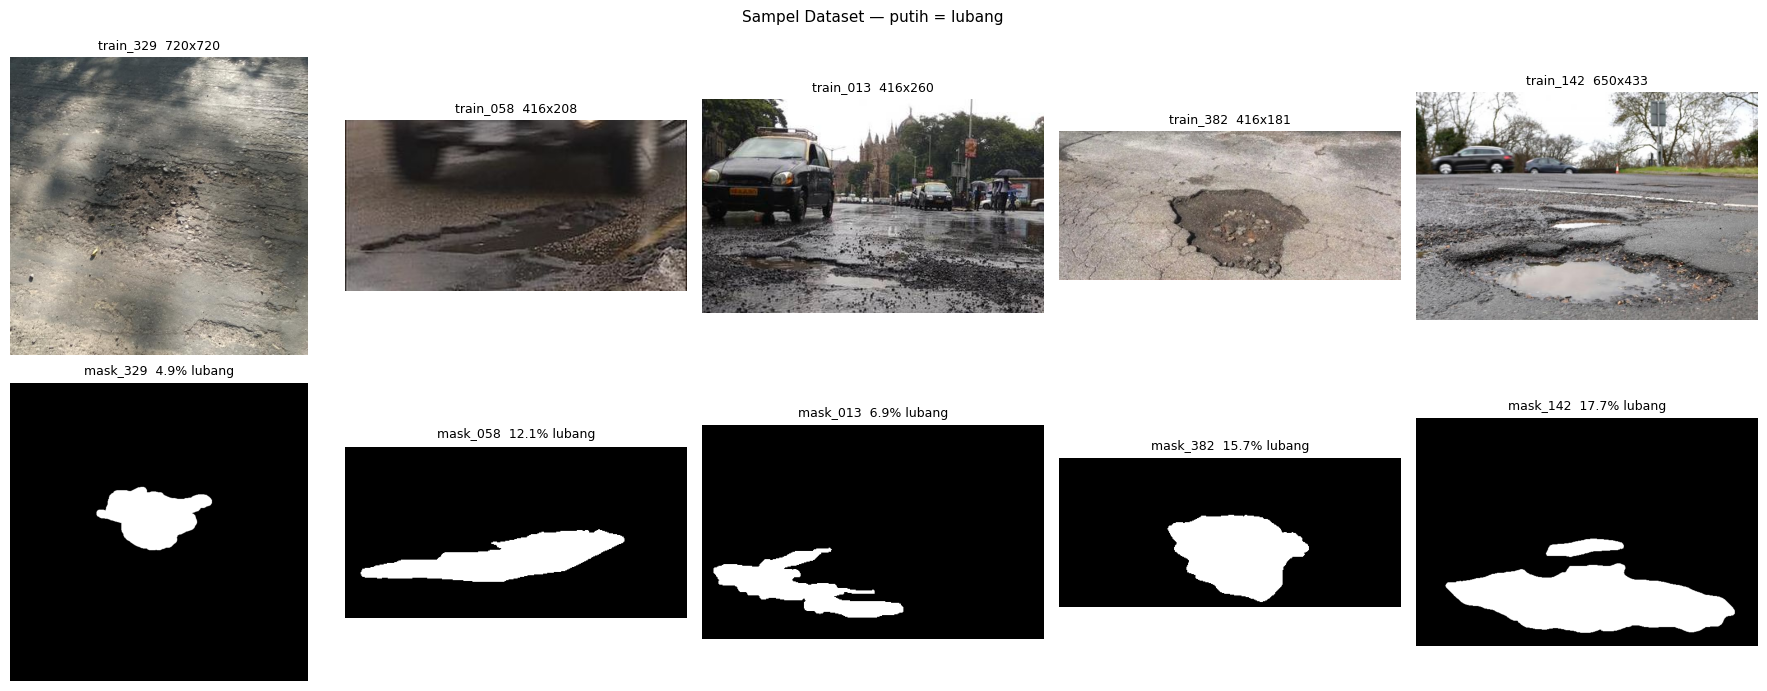

In [ ]:
# 2.1 Hitung file + tampilkan 5 sampel
train_imgs = sorted(TRAIN_IMG_DIR.glob('*.jpg'))
test_imgs  = sorted(TEST_IMG_DIR.glob('*.jpg'))
print(f'Training images : {len(train_imgs)}')
print(f'Test images     : {len(test_imgs)}')

samples   = random.sample(train_imgs, 5)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, p in enumerate(samples):
    idx = p.stem.split('_')[1]
    bgr = cv2.imread(str(p))
    msk = cv2.imread(str(TRAIN_MSK_DIR / f'mask_{idx}.png'), cv2.IMREAD_GRAYSCALE)
    show_img(axes[0, i], bgr, f'train_{idx}  {bgr.shape[1]}x{bgr.shape[0]}')
    show_img(axes[1, i], msk, f'mask_{idx}  {(msk>MASK_THRESH).mean()*100:.1f}% lubang')
axes[0, 0].set_ylabel('Gambar Asli', fontsize=10)
axes[1, 0].set_ylabel('GT Mask', fontsize=10)
plt.suptitle('Sampel Dataset — putih = lubang', fontsize=11)
plt.tight_layout()
plt.show()

Area lubang per gambar:
  Rata-rata : 13.49%
  Median    : 9.17%
  Min       : 0.02%
  Max       : 67.40%


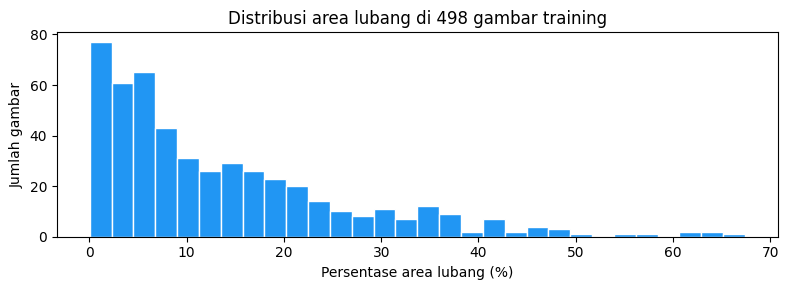

In [ ]:
# 2.2 Statistik area lubang
pcts = []
for mp in sorted(TRAIN_MSK_DIR.glob('*.png')):
    m = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
    if m is not None:
        pcts.append((m > MASK_THRESH).mean() * 100)
pcts = np.array(pcts)
print(f'Area lubang per gambar:')
print(f'  Rata-rata : {pcts.mean():.2f}%')
print(f'  Median    : {np.median(pcts):.2f}%')
print(f'  Min       : {pcts.min():.2f}%')
print(f'  Max       : {pcts.max():.2f}%')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(pcts, bins=30, color='#2196F3', edgecolor='white')
ax.set_xlabel('Persentase area lubang (%)')
ax.set_ylabel('Jumlah gambar')
ax.set_title('Distribusi area lubang di 498 gambar training')
plt.tight_layout()
plt.show()

In [ ]:
# 2.3 Ekstrak fitur superpixel semua 498 gambar → CSV (sekali jalan, ~5-8 menit)
# Jika CSV sudah ada, skip cell ini dan lanjut ke cell berikutnya.

def build_superpixel_csv(img_dir, mask_dir, out_path, verbose=True):
    """Ekstrak 10-ch fitur superpixel dari semua gambar → simpan ke CSV.
    
    Setiap baris = 1 superpixel dari 1 gambar.
    Kolom: image_name, superpixel_id, [10 fitur], label
    """
    rows     = []
    all_imgs = sorted(img_dir.glob('*.jpg'))
    for i, p in enumerate(all_imgs):
        idx     = p.stem.split('_')[1]
        bgr     = cv2.imread(str(p))
        gt_mask = cv2.imread(str(mask_dir / f'mask_{idx}.png'), cv2.IMREAD_GRAYSCALE)
        if bgr is None or gt_mask is None:
            continue

        hs, ws   = int(bgr.shape[0] * TRAIN_SCALE), int(bgr.shape[1] * TRAIN_SCALE)
        bgr_s    = cv2.resize(bgr,     (ws, hs), interpolation=cv2.INTER_AREA)
        mask_s   = cv2.resize(gt_mask, (ws, hs), interpolation=cv2.INTER_NEAREST)

        prep     = preprocess(bgr_s)
        feat_map = extract_features_10ch(bgr_s, prep)
        segments = compute_superpixels(bgr_s)
        sp_feats = aggregate_features(feat_map, segments)
        sp_lbls  = label_superpixels(segments, mask_s)

        for sp_id in range(len(sp_lbls)):
            row = {'image_name': p.stem, 'superpixel_id': sp_id}
            for fi, fn in enumerate(FEATURE_NAMES_10):
                row[fn] = round(float(sp_feats[sp_id, fi]), 5)
            row['label'] = int(sp_lbls[sp_id])
            rows.append(row)

        if verbose and (i + 1) % 100 == 0:
            print(f'  {i+1}/{len(all_imgs)} gambar selesai')

    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False)
    if verbose:
        n_tot = len(df)
        n_pos = int(df['label'].sum())
        print(f'\nCSV disimpan: {out_path}')
        print(f'Total baris : {n_tot:,}  ({len(all_imgs)} gambar x ~{n_tot//len(all_imgs)} superpixel/gambar)')
        print(f'Lubang      : {n_pos:,} ({n_pos/n_tot*100:.1f}%)  —  Jalan: {n_tot-n_pos:,} ({(n_tot-n_pos)/n_tot*100:.1f}%)')
    return df

if SP_CSV.exists():
    print(f'CSV sudah ada: {SP_CSV}  — skip ekstraksi.')
    print('Jalankan: SP_CSV.unlink() lalu re-run cell ini untuk rebuild.')
    df_sp_all = pd.read_csv(SP_CSV)
    print(f'Dimuat: {len(df_sp_all):,} baris dari {df_sp_all["image_name"].nunique()} gambar.')
else:
    print('Mulai ekstraksi... (~5-8 menit)')
    df_sp_all = build_superpixel_csv(TRAIN_IMG_DIR, TRAIN_MSK_DIR, SP_CSV)

Mulai ekstraksi... (~5-8 menit)
  100/498 gambar selesai
  200/498 gambar selesai
  300/498 gambar selesai
  400/498 gambar selesai

CSV disimpan: /Users/fadh/Documents/BINUS/Semester 4/Project_Pothole_CV/results/superpixel_features.csv
Total baris : 113,750  (498 gambar x ~228 superpixel/gambar)
Lubang      : 16,404 (14.4%)  —  Jalan: 97,346 (85.6%)


In [ ]:
# 2.4 Split 80:20 per gambar -> sp_train.csv + sp_val.csv

if 'df_sp_all' not in dir():
    df_sp_all = pd.read_csv(SP_CSV)

# Shuffle list gambar dengan seed tetap agar split selalu sama
all_img_names = sorted(df_sp_all['image_name'].unique().tolist())
rng           = random.Random(RF_SEED)
rng.shuffle(all_img_names)

n_train      = int(len(all_img_names) * TRAIN_VAL_SPLIT)
train_names  = set(all_img_names[:n_train])
val_names    = set(all_img_names[n_train:])

df_sp_train = df_sp_all[df_sp_all['image_name'].isin(train_names)].reset_index(drop=True)
df_sp_val   = df_sp_all[df_sp_all['image_name'].isin(val_names)].reset_index(drop=True)

df_sp_train.to_csv(SP_TRAIN_CSV, index=False)
df_sp_val.to_csv(SP_VAL_CSV,   index=False)

# Path gambar val untuk evaluasi pixel-level di Bagian 3-5
val_img_paths = sorted([TRAIN_IMG_DIR / f'{n}.jpg' for n in val_names])

print(f'=== Split {int(TRAIN_VAL_SPLIT*100)}/{int((1-TRAIN_VAL_SPLIT)*100)} per Gambar ===')
print(f'Train : {len(train_names):3d} gambar  →  {len(df_sp_train):,} superpixel  '
      f'(lubang {df_sp_train["label"].mean()*100:.1f}%)')
print(f'Val   : {len(val_names):3d} gambar  →  {len(df_sp_val):,} superpixel  '
      f'(lubang {df_sp_val["label"].mean()*100:.1f}%)')
print(f'\nSplit konsisten: distribusi kelas train vs val hampir sama (label seimbang).')
print(f'\nCSV disimpan:')
print(f'  Train: {SP_TRAIN_CSV}')
print(f'  Val  : {SP_VAL_CSV}')

=== Split 80/19 per Gambar ===
Train : 398 gambar  →  90,743 superpixel  (lubang 14.3%)
Val   : 100 gambar  →  23,007 superpixel  (lubang 14.7%)

Split konsisten: distribusi kelas train vs val hampir sama (label seimbang).

CSV disimpan:
  Train: /Users/fadh/Documents/BINUS/Semester 4/Project_Pothole_CV/results/sp_train.csv
  Val  : /Users/fadh/Documents/BINUS/Semester 4/Project_Pothole_CV/results/sp_val.csv


In [ ]:
# 2.5 Lihat tabel fitur: apa yang RF lihat untuk setiap superpixel
if 'df_sp_val' not in dir():
    df_sp_val = pd.read_csv(SP_VAL_CSV)

cols_show = ['image_name', 'superpixel_id'] + FEATURE_NAMES_10 + ['label']

print('=== 5 Superpixel LUBANG (label=1) dari Val Set ===')
print(df_sp_val[df_sp_val['label'] == 1][cols_show].head(5).to_string(index=False))
print()
print('=== 5 Superpixel JALAN (label=0) dari Val Set ===')
print(df_sp_val[df_sp_val['label'] == 0][cols_show].head(5).to_string(index=False))

print()
print('=== Rata-Rata Fitur per Kelas (Val Set) ===')
mean_cls = df_sp_val.groupby('label')[FEATURE_NAMES_10].mean().round(4)
mean_cls.index = ['Jalan (0)', 'Lubang (1)']
print(mean_cls.T.to_string())
print()
print('Catatan: Lubang cenderung lebih gelap (Intensity rendah), lebih halus teksturnya,')
print('tapi punya saturasi HSV lebih rendah dan respons LoG/Harris yang berbeda dari aspal.')

=== 5 Superpixel LUBANG (label=1) dari Val Set ===
image_name  superpixel_id  Intensity  Local Std Dev  Local Range  Gradient Mag  HSV Hue  HSV Sat  HSV Val  Harris Corners  LoG Blob  HOG Entropy  label
 train_004            157    0.31523        0.23337      0.50137       0.12250  0.55036  0.07592  0.27068         0.00089   0.09056      0.38635      1
 train_004            158    0.33428        0.24191      0.48584       0.13686  0.60267  0.07806  0.29491         0.00305   0.09653      0.34175      1
 train_004            161    0.20744        0.31775      0.56076       0.14729  0.49514  0.10591  0.20461         0.00139   0.22414      0.39664      1
 train_004            162    0.24974        0.24042      0.50606       0.11195  0.65668  0.07205  0.23207         0.00143   0.13406      0.40485      1
 train_004            165    0.39897        0.20786      0.44781       0.10969  0.82425  0.06544  0.30691         0.00083   0.06343      0.36591      1

=== 5 Superpixel JALAN (label=0) dar

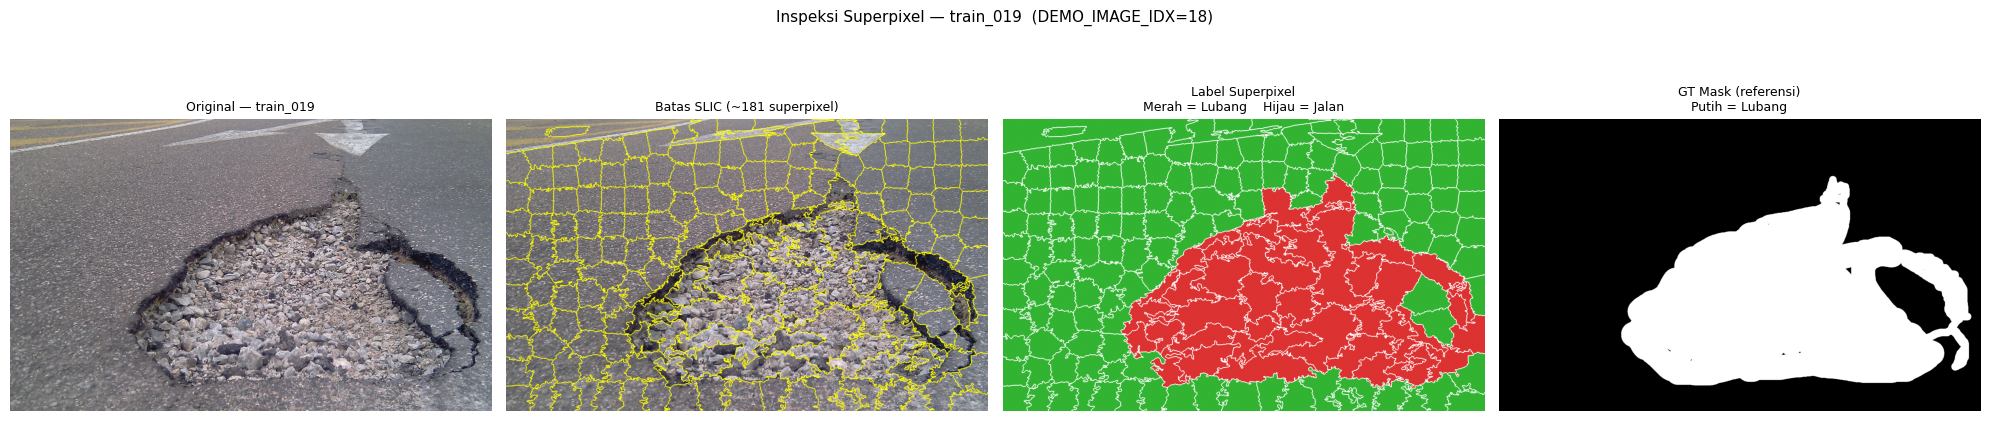

Gambar ini punya 181 superpixel: 41 lubang, 140 jalan.
Setiap superpixel = 1 baris di CSV. RF belajar dari ~72,038 baris (398 gambar train).


In [48]:
# 2.6 Visualisasi superpixel pada demo gambar (DEMO_IMAGE_IDX dari Bagian 0)
from skimage.segmentation import mark_boundaries

sp_demo_bgr  = cv2.imread(str(train_imgs[DEMO_IMAGE_IDX]))
sp_demo_stem = train_imgs[DEMO_IMAGE_IDX].stem
sp_demo_idx  = sp_demo_stem.split('_')[1]
sp_demo_gt   = cv2.imread(str(TRAIN_MSK_DIR / f'mask_{sp_demo_idx}.png'), cv2.IMREAD_GRAYSCALE)

hs, ws        = int(sp_demo_bgr.shape[0] * TRAIN_SCALE), int(sp_demo_bgr.shape[1] * TRAIN_SCALE)
sp_demo_bgr_s = cv2.resize(sp_demo_bgr, (ws, hs), interpolation=cv2.INTER_AREA)
sp_demo_gt_s  = cv2.resize(sp_demo_gt,  (ws, hs), interpolation=cv2.INTER_NEAREST)

sp_demo_prep  = preprocess(sp_demo_bgr_s)
sp_demo_segs  = compute_superpixels(sp_demo_bgr_s)
sp_demo_feat  = extract_features_10ch(sp_demo_bgr_s, sp_demo_prep)
sp_demo_lbls  = label_superpixels(sp_demo_segs, sp_demo_gt_s)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
show_img(axes[0], sp_demo_bgr, f'Original — {sp_demo_stem}')

sp_rgb  = cv2.cvtColor(sp_demo_bgr_s, cv2.COLOR_BGR2RGB)
bounded = mark_boundaries(sp_rgb, sp_demo_segs, color=(1, 1, 0), mode='thin')
axes[1].imshow(bounded)
axes[1].set_title(f'Batas SLIC (~{sp_demo_segs.max()+1} superpixel)', fontsize=9)
axes[1].axis('off')

label_map = np.zeros((*sp_demo_segs.shape, 3), dtype=np.uint8)
for sp_id in range(len(sp_demo_lbls)):
    label_map[sp_demo_segs == sp_id] = (220, 50, 50) if sp_demo_lbls[sp_id] == 1 else (50, 180, 50)
bounded_lm = mark_boundaries(label_map, sp_demo_segs, color=(1, 1, 1), mode='thin')
axes[2].imshow(bounded_lm)
axes[2].set_title('Label Superpixel\nMerah = Lubang    Hijau = Jalan', fontsize=9)
axes[2].axis('off')

show_img(axes[3], sp_demo_gt, 'GT Mask (referensi)\nPutih = Lubang')

plt.suptitle(f'Inspeksi Superpixel — {sp_demo_stem}  (DEMO_IMAGE_IDX={DEMO_IMAGE_IDX})', fontsize=11)
plt.tight_layout()
plt.show()

n_hole = int(sp_demo_lbls.sum())
print(f'Gambar ini punya {len(sp_demo_lbls)} superpixel: {n_hole} lubang, {len(sp_demo_lbls)-n_hole} jalan.')
print(f'Setiap superpixel = 1 baris di CSV. RF belajar dari ~{len(sp_demo_lbls)*398:,} baris (398 gambar train).')

# 3 — Model 1: Baseline (Adaptive Thresholding)

**Cara kerja:** Preprocessing → Adaptive Gaussian Threshold → piksel lebih gelap dari tetangga lokalnya = kandidat lubang.

**Kelebihan:** Sangat cepat, tidak perlu training, deterministik.  
**Kelemahan:** Hanya menggunakan 1 sinyal (kecerahan lokal) — bayangan dan noda aspal mudah salah terdeteksi.

In [28]:
def detect_baseline(bgr):
    """Deteksi lubang dengan Adaptive Thresholding.
    Returns: mask biner uint8 (255 = lubang).
    """
    road_mask = segment_road(bgr)
    prep      = preprocess(bgr)

    # block_size=35 tangkap konteks lokal yang cukup besar
    # C=8 pastikan hanya yang jauh lebih gelap dari rata-rata sekitarnya yang terdeteksi
    thresh  = cv2.adaptiveThreshold(
        prep, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 35, 8
    )
    pothole = cv2.bitwise_not(thresh)          # invert: area gelap = lubang
    pothole = cv2.bitwise_and(pothole, road_mask)
    pothole[:int(bgr.shape[0] * TOP_CROP_PCT)] = 0
    return postprocess(pothole)


print('detect_baseline OK.')

detect_baseline OK.


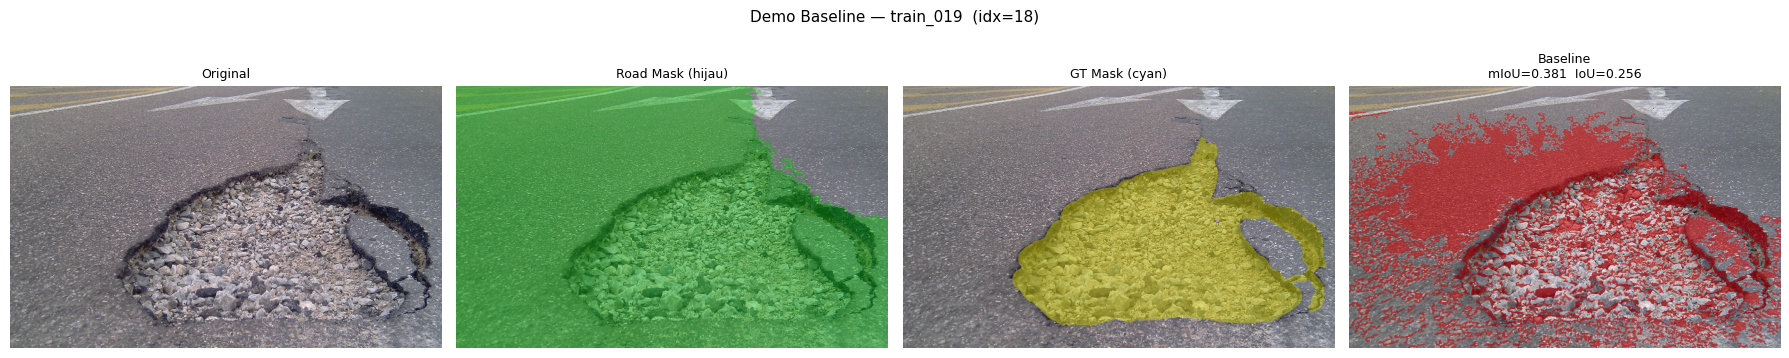

In [49]:
# Demo pada gambar index DEMO_IMAGE_IDX (ubah nilai di Bagian 0 untuk gambar lain)
demo_path = train_imgs[DEMO_IMAGE_IDX]
demo_idx  = demo_path.stem.split('_')[1]
demo_bgr  = cv2.imread(str(demo_path))
demo_gt   = cv2.imread(str(TRAIN_MSK_DIR / f'mask_{demo_idx}.png'), cv2.IMREAD_GRAYSCALE)

road_demo = segment_road(demo_bgr)
pred_bl   = detect_baseline(demo_bgr)
m_bl      = compute_metrics(pred_bl, demo_gt)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
show_img(axes[0], demo_bgr,                                           'Original')
show_img(axes[1], make_overlay(demo_bgr, road_demo, (0,200,0), 0.4), 'Road Mask (hijau)')
show_img(axes[2], make_overlay(demo_bgr, demo_gt,   (0,200,200), 0.5), 'GT Mask (cyan)')
show_img(axes[3], make_overlay(demo_bgr, pred_bl,   (0,0,220), 0.5),
         f"Baseline\nmIoU={m_bl['mIoU']:.3f}  IoU={m_bl['IoU_Pothole']:.3f}")
plt.suptitle(f'Demo Baseline — train_{demo_idx}  (idx={DEMO_IMAGE_IDX})', fontsize=11)
plt.tight_layout()
plt.show()

In [30]:
# Evaluasi Baseline pada 100 gambar val (held-out — tidak dipakai saat training RF)
# Baseline & K-Means bersifat unsupervised (tidak ada training), tapi kita evaluasi
# pada val set agar perbandingan antar semua model fair pada data yang sama.
if 'val_img_paths' not in dir():
    _val_df      = pd.read_csv(SP_VAL_CSV)
    val_img_paths = sorted([TRAIN_IMG_DIR / f'{n}.jpg' for n in _val_df['image_name'].unique()])

rows_bl = []
for p in val_img_paths:
    idx = p.stem.split('_')[1]
    bgr = cv2.imread(str(p))
    gt  = cv2.imread(str(TRAIN_MSK_DIR / f'mask_{idx}.png'), cv2.IMREAD_GRAYSCALE)
    if bgr is None or gt is None:
        continue
    rows_bl.append({'image': p.stem, **compute_metrics(detect_baseline(bgr), gt)})

df_bl = pd.DataFrame(rows_bl)
df_bl.to_csv(RESULTS_DIR / 'baseline_metrics.csv', index=False)
print(f'=== Baseline — Rata-Rata Metrik ({len(df_bl)} gambar val) ===')
print(df_bl[['IoU_Pothole','mIoU','Dice','PixelAcc','Precision','Recall']].mean().round(4).to_string())

=== Baseline — Rata-Rata Metrik (100 gambar val) ===
IoU_Pothole    0.1827
mIoU           0.4028
Dice           0.2795
PixelAcc       0.6676
Precision      0.2386
Recall         0.5650


# 4 — Model 2: Advanced (K-Means Pixel Clustering)

**Cara kerja:** Preprocessing → K-Means (K=3) pada intensitas piksel → cluster paling gelap = kandidat lubang.

**Kelebihan:** Lebih adaptif dari threshold tunggal, tidak perlu training.  
**Kelemahan:** Cluster "gelap" tidak tahu apa itu lubang — bisa berisi bayangan atau noda.

In [31]:
def detect_kmeans(bgr):
    """Deteksi lubang dengan K-Means clustering intensitas piksel (K=3).
    Returns: mask biner uint8 (255 = lubang).
    """
    road_mask = segment_road(bgr)
    h, w      = bgr.shape[:2]
    ws, hs    = int(w * WORK_SCALE), int(h * WORK_SCALE)
    bgr_s     = cv2.resize(bgr,       (ws, hs), interpolation=cv2.INTER_AREA)
    road_s    = cv2.resize(road_mask, (ws, hs), interpolation=cv2.INTER_NEAREST)

    prep     = preprocess(bgr_s)
    pixels   = prep.reshape(-1, 1).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(
        pixels, K=3, bestLabels=None, criteria=criteria,
        attempts=10, flags=cv2.KMEANS_PP_CENTERS
    )

    darkest = int(np.argmin(centers.flatten()))   # cluster paling gelap = kandidat lubang
    mask_s  = (labels.reshape(hs, ws) == darkest).astype(np.uint8) * 255
    mask_s  = cv2.bitwise_and(mask_s, road_s)

    pothole = cv2.resize(mask_s, (w, h), interpolation=cv2.INTER_NEAREST)
    pothole[:int(h * TOP_CROP_PCT)] = 0

    # Sesuai proposal: hanya CLOSE + filter area kecil
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (POSTPROC_K, POSTPROC_K))
    pothole = cv2.morphologyEx(pothole, cv2.MORPH_CLOSE, k)
    contours, _ = cv2.findContours(pothole, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    result = np.zeros_like(pothole)
    for cnt in contours:
        if cv2.contourArea(cnt) >= MIN_AREA:
            cv2.drawContours(result, [cnt], -1, 255, cv2.FILLED)
    return result


print('detect_kmeans OK.')

detect_kmeans OK.


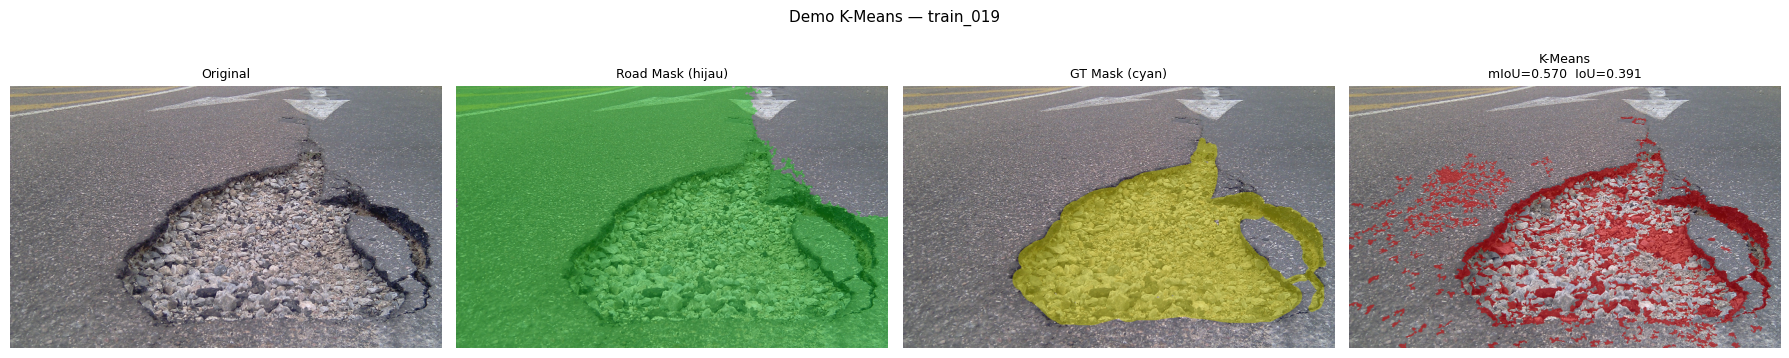

In [50]:
# Demo pada gambar yang sama dengan Baseline
pred_km = detect_kmeans(demo_bgr)
m_km    = compute_metrics(pred_km, demo_gt)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
show_img(axes[0], demo_bgr,                                         'Original')
show_img(axes[1], make_overlay(demo_bgr, road_demo, (0,200,0), 0.4), 'Road Mask (hijau)')
show_img(axes[2], make_overlay(demo_bgr, demo_gt,   (0,200,200), 0.5), 'GT Mask (cyan)')
show_img(axes[3], make_overlay(demo_bgr, pred_km,   (0,0,220), 0.5),
         f"K-Means\nmIoU={m_km['mIoU']:.3f}  IoU={m_km['IoU_Pothole']:.3f}")
plt.suptitle(f'Demo K-Means — train_{demo_idx}', fontsize=11)
plt.tight_layout()
plt.show()

In [33]:
# Evaluasi K-Means pada 100 gambar val (set yang sama dengan Baseline & RF)
if 'val_img_paths' not in dir():
    _val_df      = pd.read_csv(SP_VAL_CSV)
    val_img_paths = sorted([TRAIN_IMG_DIR / f'{n}.jpg' for n in _val_df['image_name'].unique()])

rows_km = []
for p in val_img_paths:
    idx = p.stem.split('_')[1]
    bgr = cv2.imread(str(p))
    gt  = cv2.imread(str(TRAIN_MSK_DIR / f'mask_{idx}.png'), cv2.IMREAD_GRAYSCALE)
    if bgr is None or gt is None:
        continue
    rows_km.append({'image': p.stem, **compute_metrics(detect_kmeans(bgr), gt)})

df_km = pd.DataFrame(rows_km)
df_km.to_csv(RESULTS_DIR / 'kmeans_metrics.csv', index=False)
print(f'=== K-Means — Rata-Rata Metrik ({len(df_km)} gambar val) ===')
print(df_km[['IoU_Pothole','mIoU','Dice','PixelAcc','Precision','Recall']].mean().round(4).to_string())

=== K-Means — Rata-Rata Metrik (100 gambar val) ===
IoU_Pothole    0.1530
mIoU           0.4432
Dice           0.2397
PixelAcc       0.7499
Precision      0.2436
Recall         0.3581


# 5 — Model 3: Experiment (Random Forest + SLIC Superpixel)

**Cara kerja:**
1. Gambar dibagi menjadi ~250 superpixel (SLIC — kelompok piksel yang berdekatan dan serupa)
2. Setiap superpixel diwakili rata-rata fitur pixel-nya
3. Random Forest dilatih dari 498 pasangan (fitur superpixel, label GT lubang/bukan)
4. Saat inferensi: superpixel diprediksi lubang atau bukan → dikembalikan ke mask piksel

**Mengapa lebih baik dari K-Means?** K-Means tidak pernah melihat contoh lubang nyata.  
RF dilatih dari 498 GT mask — tahu kombinasi fitur yang membedakan lubang dari bayangan/retak/noda.

**Dua varian diuji:**
- **RF-4ch** — hanya 4 fitur grayscale dasar (Intensity, Std Dev, Local Range, Gradient)
- **RF-10ch** — 4 fitur di atas + 3 fitur warna HSV + 3 fitur geometri tepi (Harris, LoG, HOG)

Perbandingan ini menunjukkan seberapa besar kontribusi fitur warna dan geometri tepi.

In [34]:
def train_rf_model(n_features=10, csv_path=None, verbose=True):
    """Latih Random Forest dari sp_train.csv (80% gambar training, tanpa data leakage).

    n_features: 4 → pakai 4 fitur pertama, 10 → pakai semua 10 fitur
    csv_path  : path ke sp_train.csv (default: SP_TRAIN_CSV dari Bagian 0)
    Returns   : RandomForestClassifier yang sudah di-fit
    """
    if csv_path is None:
        csv_path = SP_TRAIN_CSV

    df   = pd.read_csv(csv_path)
    feat = FEATURE_NAMES_10[:n_features]
    X    = df[feat].values.astype(np.float32)
    y    = df['label'].values.astype(np.int32)

    if verbose:
        n_pos = int(y.sum())
        print(f'Fitur ({n_features}ch) : {feat}')
        print(f'Superpixel train  : {len(X):,}  —  Lubang: {n_pos:,} ({n_pos/len(y)*100:.1f}%)  '
              f'Jalan: {len(y)-n_pos:,}')
        print('Melatih Random Forest...')

    clf = RandomForestClassifier(
        n_estimators=RF_N_EST,
        max_depth=RF_MAX_DEPTH,
        min_samples_leaf=RF_MIN_LEAF,
        class_weight='balanced',   # tangani ketidakseimbangan kelas ~5-15% pothole
        random_state=RF_SEED,
        n_jobs=-1,
    )
    clf.fit(X, y)
    if verbose:
        print('Training selesai.')
    return clf

print('train_rf_model OK.')

train_rf_model OK.


In [35]:
# Training RF-4ch dari sp_train.csv (398 gambar, jauh lebih cepat dari proses raw images)
print('=== Training RF-4ch ===')
clf_4ch = train_rf_model(n_features=4)
joblib.dump(clf_4ch, MODEL_DIR / 'model_rf_4ch.joblib')
print(f'Model disimpan: {MODEL_DIR / "model_rf_4ch.joblib"}')

=== Training RF-4ch ===
Fitur (4ch) : ['Intensity', 'Local Std Dev', 'Local Range', 'Gradient Mag']
Superpixel train  : 90,743  —  Lubang: 13,013 (14.3%)  Jalan: 77,730
Melatih Random Forest...
Training selesai.
Model disimpan: /Users/fadh/Documents/BINUS/Semester 4/Project_Pothole_CV/model/model_rf_4ch.joblib


In [36]:
# Training RF-10ch dari sp_train.csv
print('=== Training RF-10ch ===')
clf_10ch = train_rf_model(n_features=10)
joblib.dump(clf_10ch, MODEL_DIR / 'model_rf_10ch.joblib')
print(f'Model disimpan: {MODEL_DIR / "model_rf_10ch.joblib"}')

=== Training RF-10ch ===
Fitur (10ch) : ['Intensity', 'Local Std Dev', 'Local Range', 'Gradient Mag', 'HSV Hue', 'HSV Sat', 'HSV Val', 'Harris Corners', 'LoG Blob', 'HOG Entropy']
Superpixel train  : 90,743  —  Lubang: 13,013 (14.3%)  Jalan: 77,730
Melatih Random Forest...
Training selesai.
Model disimpan: /Users/fadh/Documents/BINUS/Semester 4/Project_Pothole_CV/model/model_rf_10ch.joblib


In [37]:
# Jika model sudah ada, load dari sini — skip dua cell training di atas
# clf_4ch  = joblib.load(MODEL_DIR / 'model_rf_4ch.joblib')
# clf_10ch = joblib.load(MODEL_DIR / 'model_rf_10ch.joblib')
# print('Model dimuat dari disk.')

In [38]:
def detect_rf(bgr, clf, n_features=10):
    """Deteksi lubang dengan Random Forest pada fitur superpixel SLIC.

    n_features: 4 atau 10 — harus sesuai dengan model yang diberikan
    Returns: mask biner uint8 (255 = lubang).
    """
    extract_fn = extract_features_10ch if n_features == 10 else extract_features_4ch
    road_mask  = segment_road(bgr)
    h, w       = bgr.shape[:2]
    ws, hs     = int(w * WORK_SCALE), int(h * WORK_SCALE)

    bgr_s  = cv2.resize(bgr,       (ws, hs), interpolation=cv2.INTER_AREA)
    road_s = cv2.resize(road_mask, (ws, hs), interpolation=cv2.INTER_NEAREST)

    prep      = preprocess(bgr_s)
    feat_map  = extract_fn(bgr_s, prep)
    segments  = compute_superpixels(bgr_s)
    sp_feats  = aggregate_features(feat_map, segments)

    pred_labels  = clf.predict(sp_feats)
    pothole_segs = np.where(pred_labels == 1)[0]
    mask_s       = np.isin(segments, pothole_segs).astype(np.uint8) * 255
    mask_s       = cv2.bitwise_and(mask_s, road_s)

    pothole = cv2.resize(mask_s, (w, h), interpolation=cv2.INTER_NEAREST)
    pothole[:int(h * TOP_CROP_PCT)] = 0
    return postprocess(pothole)


print('detect_rf OK.')

detect_rf OK.


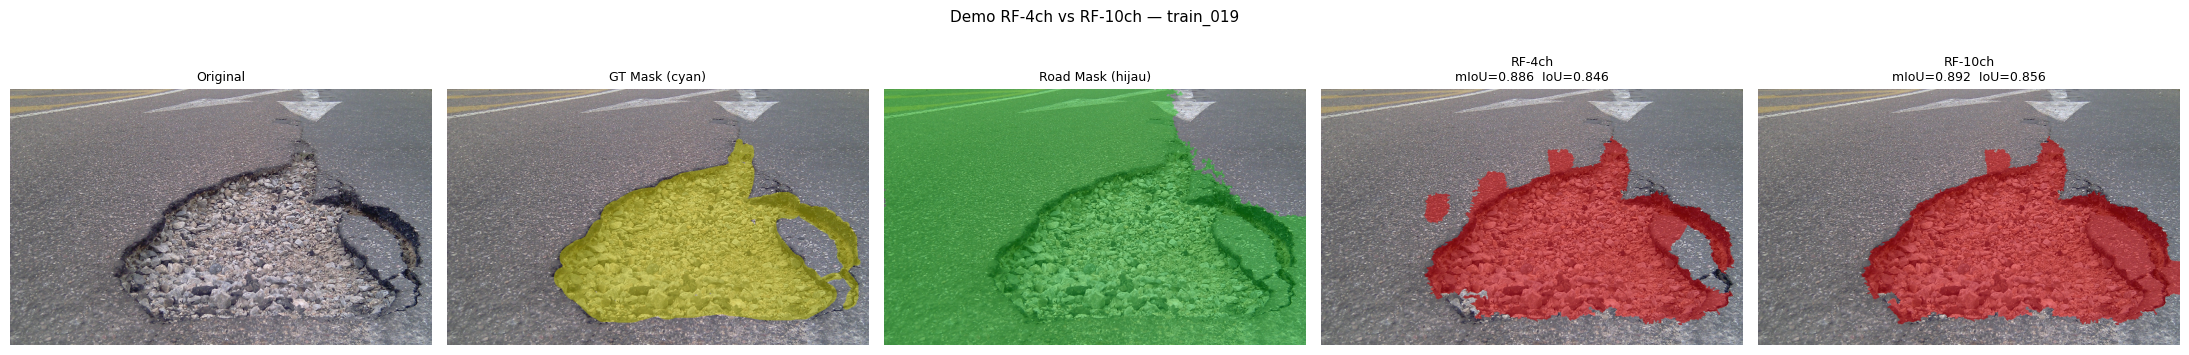


Selisih IoU_Pothole (10ch - 4ch): 0.0098


In [51]:
# Demo: RF-4ch vs RF-10ch pada gambar yang sama
pred_rf4  = detect_rf(demo_bgr, clf_4ch,  n_features=4)
pred_rf10 = detect_rf(demo_bgr, clf_10ch, n_features=10)
m_rf4     = compute_metrics(pred_rf4,  demo_gt)
m_rf10    = compute_metrics(pred_rf10, demo_gt)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
show_img(axes[0], demo_bgr,                                          'Original')
show_img(axes[1], make_overlay(demo_bgr, demo_gt, (0,200,200), 0.5), 'GT Mask (cyan)')
show_img(axes[2], make_overlay(demo_bgr, road_demo, (0,200,0), 0.4), 'Road Mask (hijau)')
show_img(axes[3], make_overlay(demo_bgr, pred_rf4,  (0,0,220), 0.5),
         f"RF-4ch\nmIoU={m_rf4['mIoU']:.3f}  IoU={m_rf4['IoU_Pothole']:.3f}")
show_img(axes[4], make_overlay(demo_bgr, pred_rf10, (0,0,220), 0.5),
         f"RF-10ch\nmIoU={m_rf10['mIoU']:.3f}  IoU={m_rf10['IoU_Pothole']:.3f}")
plt.suptitle(f'Demo RF-4ch vs RF-10ch — train_{demo_idx}', fontsize=11)
plt.tight_layout()
plt.show()
print('\nSelisih IoU_Pothole (10ch - 4ch):', round(m_rf10['IoU_Pothole'] - m_rf4['IoU_Pothole'], 4))

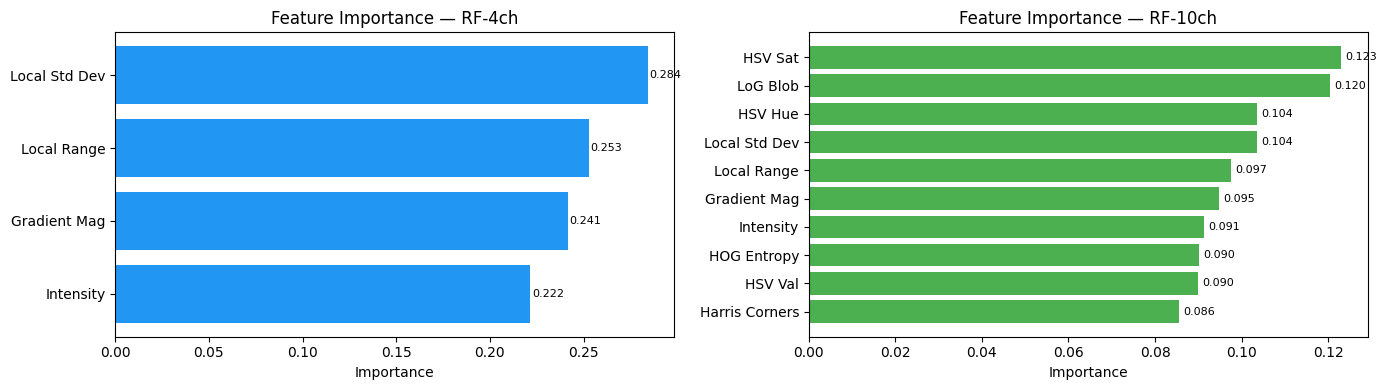

In [40]:
# Feature importance: 4ch vs 10ch
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

for ax, clf, names, color, title in [
    (ax1, clf_4ch,  FEATURE_NAMES_4,  '#2196F3', 'RF-4ch'),
    (ax2, clf_10ch, FEATURE_NAMES_10, '#4CAF50', 'RF-10ch'),
]:
    imp     = clf.feature_importances_
    idx     = np.argsort(imp)
    ax.barh([names[i] for i in idx], imp[idx], color=color)
    ax.set_title(f'Feature Importance — {title}')
    ax.set_xlabel('Importance')
    for i, (fi, ni) in enumerate(zip(imp[idx], idx)):
        ax.text(fi + 0.001, i, f'{fi:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [41]:
# Evaluasi RF-4ch pada 100 gambar val (held-out, tidak dilihat saat training — tidak ada leakage)
if 'val_img_paths' not in dir():
    _val_df      = pd.read_csv(SP_VAL_CSV)
    val_img_paths = sorted([TRAIN_IMG_DIR / f'{n}.jpg' for n in _val_df['image_name'].unique()])

rows_rf4 = []
for p in val_img_paths:
    idx = p.stem.split('_')[1]
    bgr = cv2.imread(str(p))
    gt  = cv2.imread(str(TRAIN_MSK_DIR / f'mask_{idx}.png'), cv2.IMREAD_GRAYSCALE)
    if bgr is None or gt is None:
        continue
    rows_rf4.append({'image': p.stem, **compute_metrics(detect_rf(bgr, clf_4ch, 4), gt)})

df_rf4 = pd.DataFrame(rows_rf4)
df_rf4.to_csv(RESULTS_DIR / 'rf_4ch_metrics.csv', index=False)
print(f'=== RF-4ch — Rata-Rata Metrik ({len(df_rf4)} gambar val, tanpa data leakage) ===')
print(df_rf4[['IoU_Pothole','mIoU','Dice','PixelAcc','Precision','Recall']].mean().round(4).to_string())

=== RF-4ch — Rata-Rata Metrik (100 gambar val, tanpa data leakage) ===
IoU_Pothole    0.1754
mIoU           0.4825
Dice           0.2705
PixelAcc       0.8081
Precision      0.3173
Recall         0.3292


In [42]:
# Evaluasi RF-10ch pada 100 gambar val (set yang sama dengan semua model lain)
if 'val_img_paths' not in dir():
    _val_df      = pd.read_csv(SP_VAL_CSV)
    val_img_paths = sorted([TRAIN_IMG_DIR / f'{n}.jpg' for n in _val_df['image_name'].unique()])

rows_rf10 = []
for p in val_img_paths:
    idx = p.stem.split('_')[1]
    bgr = cv2.imread(str(p))
    gt  = cv2.imread(str(TRAIN_MSK_DIR / f'mask_{idx}.png'), cv2.IMREAD_GRAYSCALE)
    if bgr is None or gt is None:
        continue
    rows_rf10.append({'image': p.stem, **compute_metrics(detect_rf(bgr, clf_10ch, 10), gt)})

df_rf10 = pd.DataFrame(rows_rf10)
df_rf10.to_csv(RESULTS_DIR / 'rf_10ch_metrics.csv', index=False)
print(f'=== RF-10ch — Rata-Rata Metrik ({len(df_rf10)} gambar val, tanpa data leakage) ===')
print(df_rf10[['IoU_Pothole','mIoU','Dice','PixelAcc','Precision','Recall']].mean().round(4).to_string())

=== RF-10ch — Rata-Rata Metrik (100 gambar val, tanpa data leakage) ===
IoU_Pothole    0.2371
mIoU           0.5221
Dice           0.3451
PixelAcc       0.8263
Precision      0.3870
Recall         0.4086


## Bagian 6 — Perbandingan & Ringkasan Semua Model

In [43]:
# Load dari CSV jika belum ada di memory
if 'df_bl'   not in dir(): df_bl   = pd.read_csv(RESULTS_DIR / 'baseline_metrics.csv')
if 'df_km'   not in dir(): df_km   = pd.read_csv(RESULTS_DIR / 'kmeans_metrics.csv')
if 'df_rf4'  not in dir(): df_rf4  = pd.read_csv(RESULTS_DIR / 'rf_4ch_metrics.csv')
if 'df_rf10' not in dir(): df_rf10 = pd.read_csv(RESULTS_DIR / 'rf_10ch_metrics.csv')

cols = ['IoU_Pothole', 'mIoU', 'Dice', 'PixelAcc', 'Precision', 'Recall', 'F1']
dfs  = [df_bl, df_km, df_rf4, df_rf10]
names = ['Baseline (AT)', 'K-Means', 'RF-4ch', 'RF-10ch']

summary = pd.DataFrame(
    {col: [df[col].mean() for df in dfs] for col in cols},
    index=names
).round(4)

print('=== Ringkasan Perbandingan ===')
print(summary.to_string())
print(f'\nModel terbaik  : {summary["IoU_Pothole"].idxmax()}')
print(f'IoU_Pothole    : {summary["IoU_Pothole"].max():.4f}')
print(f'Target >= 0.60 : {"TERCAPAI" if summary["IoU_Pothole"].max() >= 0.60 else "belum tercapai"}')

=== Ringkasan Perbandingan ===
               IoU_Pothole    mIoU    Dice  PixelAcc  Precision  Recall      F1
Baseline (AT)       0.1827  0.4028  0.2795    0.6676     0.2386  0.5650  0.2795
K-Means             0.1530  0.4432  0.2397    0.7499     0.2436  0.3581  0.2397
RF-4ch              0.1754  0.4825  0.2705    0.8081     0.3173  0.3292  0.2705
RF-10ch             0.2371  0.5221  0.3451    0.8263     0.3870  0.4086  0.3451

Model terbaik  : RF-10ch
IoU_Pothole    : 0.2371
Target >= 0.60 : belum tercapai


/var/folders/v0/tvzqj0q53pl6kq77syq5n1100000gn/T/ipykernel_64585/2604333330.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([df['IoU_Pothole'].values for df in dfs], labels=names,


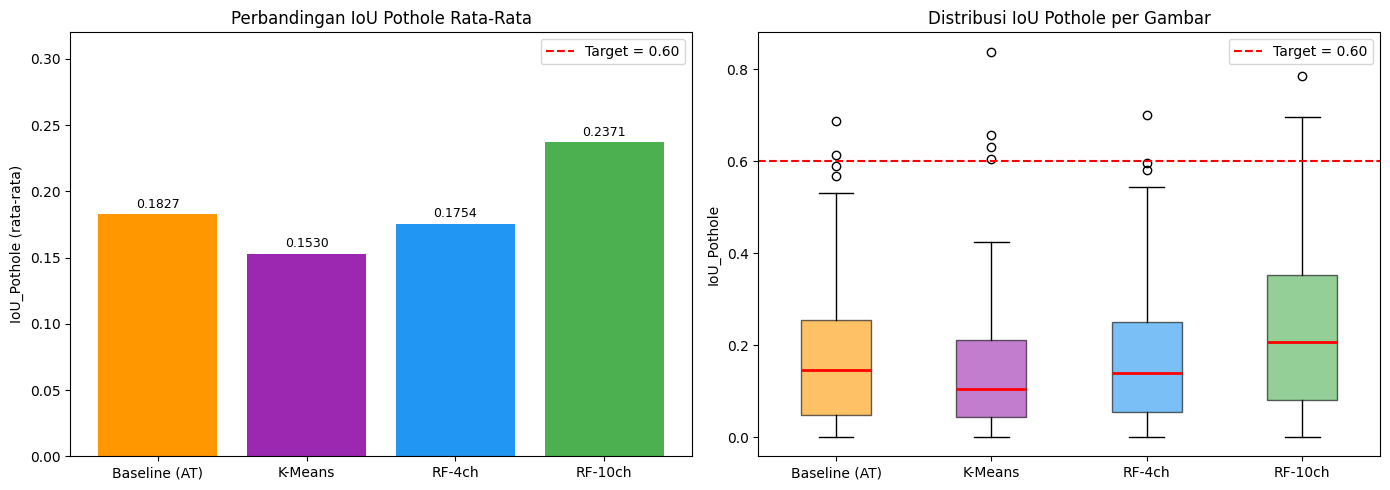

In [44]:
# Visualisasi: bar chart IoU + boxplot distribusi
colors = ['#FF9800', '#9C27B0', '#2196F3', '#4CAF50']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

iou_means = [df['IoU_Pothole'].mean() for df in dfs]
bars = ax1.bar(names, iou_means, color=colors)
ax1.axhline(0.60, color='red', linestyle='--', linewidth=1.5, label='Target = 0.60')
ax1.set_ylim(0, max(iou_means) * 1.35)
ax1.set_ylabel('IoU_Pothole (rata-rata)')
ax1.set_title('Perbandingan IoU Pothole Rata-Rata')
ax1.legend()
for bar, val in zip(bars, iou_means):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
             f'{val:.4f}', ha='center', fontsize=9)

bp = ax2.boxplot([df['IoU_Pothole'].values for df in dfs], labels=names,
                 patch_artist=True, medianprops={'color': 'red', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.axhline(0.60, color='red', linestyle='--', linewidth=1.5, label='Target = 0.60')
ax2.set_ylabel('IoU_Pothole')
ax2.set_title('Distribusi IoU Pothole per Gambar')
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison_chart.png', dpi=120, bbox_inches='tight')
plt.show()

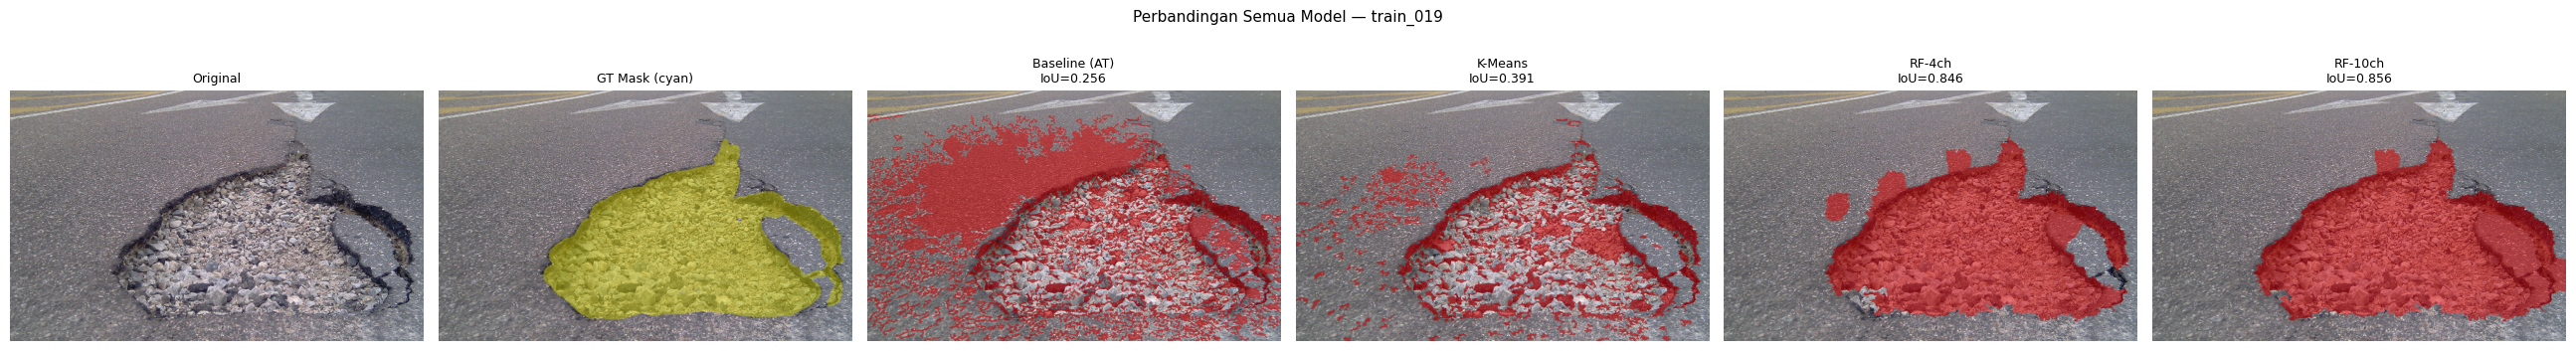

In [52]:
# Demo visual semua model pada 1 gambar
fig, axes = plt.subplots(1, 6, figsize=(26, 4))
show_img(axes[0], demo_bgr,                                          'Original')
show_img(axes[1], make_overlay(demo_bgr, demo_gt, (0,200,200), 0.5), 'GT Mask (cyan)')

for ax, name, pred in zip(axes[2:], names, [pred_bl, pred_km, pred_rf4, pred_rf10]):
    m = compute_metrics(pred, demo_gt)
    show_img(ax, make_overlay(demo_bgr, pred, (0,0,220), 0.5),
             f"{name}\nIoU={m['IoU_Pothole']:.3f}")

plt.suptitle(f'Perbandingan Semua Model — train_{demo_idx}', fontsize=11)
plt.tight_layout()
plt.show()